In [1]:
# Cell 1: load
import json
from pathlib import Path
from collections import Counter

import pandas as pd
from transformers import AutoTokenizer

items = [json.loads(l) for l in open("../data/processed/sft_train.jsonl")]
print(f"Total: {len(items)}")
print("Sources:", Counter(i["source"] for i in items))
print("Subjects:", Counter(i["subject"] for i in items))

/home/lucky/workspace/r1-distill/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total: 1200
Sources: Counter({'s1k': 1000, 'pcmb': 200})
Subjects: Counter({'math': 925, 'science': 108, 'chemistry': 60, 'physics': 54, 'biology': 38, 'crossword': 15})


In [2]:
# Cell 2: tokenize a sample with the actual Qwen tokenizer
# This is the most important check: how long is each example in REAL tokens?
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

# Tokenize 50 random examples to get a fast estimate
import random
random.seed(0)
sample = random.sample(items, min(100, len(items)))

lengths = []
for item in sample:
    # Apply the chat template — this is what ms-swift will do internally
    text = tok.apply_chat_template(item["messages"], tokenize=False)
    tokens = tok.encode(text)
    lengths.append(len(tokens))

import numpy as np
arr = np.array(lengths)
print(f"Token length stats (n={len(arr)} sample):")
print(f"  min:    {arr.min()}")
print(f"  p25:    {np.percentile(arr, 25):.0f}")
print(f"  median: {np.median(arr):.0f}")
print(f"  p75:    {np.percentile(arr, 75):.0f}")
print(f"  p95:    {np.percentile(arr, 95):.0f}")
print(f"  p99:    {np.percentile(arr, 99):.0f}")
print(f"  max:    {arr.max()}")

Token length stats (n=100 sample):
  min:    961
  p25:    6234
  median: 9554
  p75:    13589
  p95:    17384
  p99:    19698
  max:    22630


In [3]:
# Cell 3: tokenize ALL examples (takes 1-2 minutes for 1200 items)
# We need this for the final max_length decision
all_lengths = []
for item in items:
    text = tok.apply_chat_template(item["messages"], tokenize=False)
    tokens = tok.encode(text)
    all_lengths.append(len(tokens))

import numpy as np
arr = np.array(all_lengths)
print(f"FULL dataset token stats (n={len(arr)}):")
print(f"  max: {arr.max()}")
print(f"  p99: {np.percentile(arr, 99):.0f}")
print(f"  p95: {np.percentile(arr, 95):.0f}")
print(f"  p90: {np.percentile(arr, 90):.0f}")
print(f"  median: {np.median(arr):.0f}")

import math
# Choose max_length: round p99 up to nearest 1024
suggested = int(math.ceil(np.percentile(arr, 99) / 1024) * 1024)
print(f"\n>>> Recommended training max_length: {suggested} <<<")
print(f"    Captures 99% of examples; the rest will be truncated.")
print(f"    Examples exceeding {suggested}: {(arr > suggested).sum()}")

FULL dataset token stats (n=1200):
  max: 26967
  p99: 19616
  p95: 17052
  p90: 16047
  median: 8652

>>> Recommended training max_length: 20480 <<<
    Captures 99% of examples; the rest will be truncated.
    Examples exceeding 20480: 8


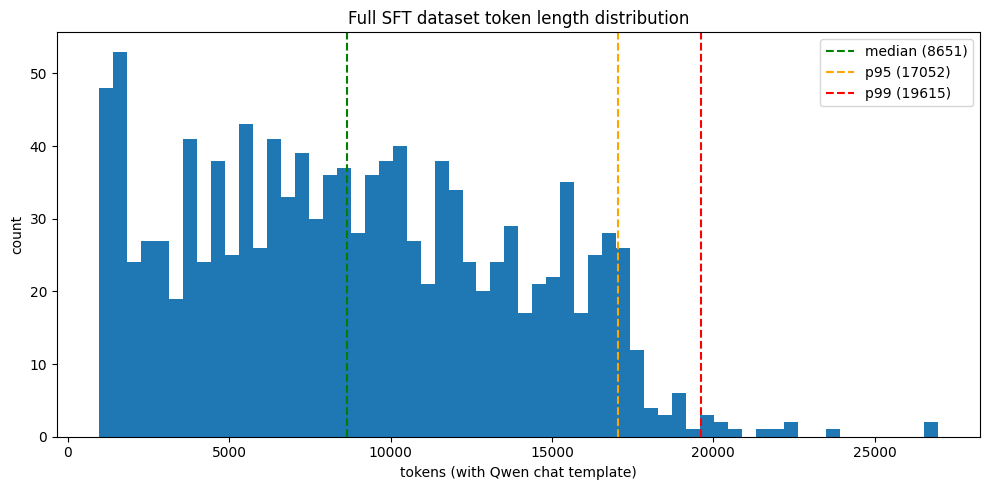

In [4]:
# Cell 4: visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(arr, bins=60)
plt.axvline(np.median(arr), color="green", linestyle="--", label=f"median ({int(np.median(arr))})")
plt.axvline(np.percentile(arr, 95), color="orange", linestyle="--", label=f"p95 ({int(np.percentile(arr, 95))})")
plt.axvline(np.percentile(arr, 99), color="red", linestyle="--", label=f"p99 ({int(np.percentile(arr, 99))})")
plt.xlabel("tokens (with Qwen chat template)")
plt.ylabel("count")
plt.title("Full SFT dataset token length distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Cell 5: source breakdown of length
df = pd.DataFrame({"length": all_lengths, "source": [i["source"] for i in items]})
print(df.groupby("source")["length"].describe().round(0))

         count     mean     std     min     25%     50%      75%      max
source                                                                   
pcmb     200.0   3609.0  3581.0  1022.0  1450.0  2056.0   4113.0  18895.0
s1k     1000.0  10036.0  4533.0   961.0  6432.0  9704.0  13540.0  26967.0
